<a href="https://colab.research.google.com/github/ihlasnijam/Northstar-analytics/blob/main/Northstar_Analytics_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
install.packages(c('sqldf','ggplot2','dplyr','tidyr',
                   'lubridate','scales','psych',
                   'GGally','reshape2'), quiet=TRUE)

library(sqldf);   library(ggplot2);  library(dplyr)
library(tidyr);   library(lubridate);library(scales)
library(psych);   library(GGally);   library(reshape2)
cat('All packages ready\n')

also installing the dependencies ‘patchwork’, ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’, ‘mnormt’, ‘GPArotation’, ‘ggstats’, ‘plyr’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘psych’


The following objects are masked from ‘package:scales’:

    alpha, rescale


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




All packages ready


In [5]:
customers  <- read.csv('customers.csv',  stringsAsFactors=FALSE)
orders     <- read.csv('orders.csv',     stringsAsFactors=FALSE)
deliveries <- read.csv('deliveries.csv', stringsAsFactors=FALSE)
drivers    <- read.csv('drivers.csv',    stringsAsFactors=FALSE)
vehicles   <- read.csv('vehicles.csv',   stringsAsFactors=FALSE)
hubs       <- read.csv('hubs.csv',       stringsAsFactors=FALSE)
complaints <- read.csv('complaints.csv', stringsAsFactors=FALSE)
incidents  <- read.csv('incidents.csv',  stringsAsFactors=FALSE)
app_events <- read.csv('app_events.csv', stringsAsFactors=FALSE)
cat('All files loaded\n')

All files loaded


In [6]:
fix_zone <- function(z) {
  z <- trimws(tolower(z))
  dplyr::case_when(
    z %in% c('central','ctr','centre') ~ 'Central',
    z == 'north'                        ~ 'North',
    z == 'south'                        ~ 'South',
    z == 'east'                         ~ 'East',
    z == 'west'                         ~ 'West',
    z == 'airport'                      ~ 'Airport',
    z == 'riverside'                    ~ 'Riverside',
    TRUE ~ tools::toTitleCase(z)
  )
}
customers$home_zone    <- fix_zone(customers$home_zone)
orders$pickup_zone     <- fix_zone(orders$pickup_zone)
orders$dropoff_zone    <- fix_zone(orders$dropoff_zone)
drivers$base_zone      <- fix_zone(drivers$base_zone)
vehicles$assigned_zone <- fix_zone(vehicles$assigned_zone)

deliveries$dispatch_time         <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at          <- ymd_hms(orders$order_created_at)

ops <- deliveries %>%
  left_join(orders,   by='order_id') %>%
  left_join(drivers,  by='driver_id') %>%
  left_join(vehicles, by='vehicle_id') %>%
  left_join(hubs,     by='hub_id') %>%
  mutate(
    actual_hours = as.numeric(difftime(
                    delivery_completed_at,
                    dispatch_time, units='hours')),
    delay_hours  = actual_hours - promised_window_hours,
    cost_per_km  = ifelse(route_distance_km > 0,
                    fuel_or_charge_cost / route_distance_km, NA),
    is_failed    = ifelse(delivery_status == 'Failed', 1, 0),
    has_override = ifelse(manual_route_override_count > 0, 1, 0)
  )
cat('ops built:', nrow(ops), 'rows x', ncol(ops), 'cols\n')

ops built: 950 rows x 46 cols


In [8]:
cat('=== SECTION 2.1: Statistical Summary ===\n')

# Select numeric variables of interest
num_vars <- ops %>%
  select(actual_hours, delay_hours, route_distance_km,
         fuel_or_charge_cost, cost_per_km,
         customer_rating_post_delivery,
         training_score, driver_rating,
         battery_health_pct, manual_route_override_count)

# Full descriptive statistics
desc <- describe(num_vars)
print(round(desc[, c('n','mean','sd','median','min','max','skew')], 3))

# Quantile breakdown for delivery delay
cat('\n--- Delay percentiles (hours) ---\n')
print(quantile(ops$delay_hours,
  probs=c(0.1,0.25,0.5,0.75,0.9,0.95), na.rm=TRUE))

=== SECTION 2.1: Statistical Summary ===
                                n  mean    sd median   min    max  skew
actual_hours                  931  9.54  8.65   7.07 -2.21  43.46  1.03
delay_hours                   931  1.98  5.54  -0.33 -5.26  19.72  1.24
route_distance_km             950 13.91  7.48  12.84  1.20  41.94  1.05
fuel_or_charge_cost           950 12.84  4.34  12.64  2.50  29.43  0.24
cost_per_km                   950  1.26  1.24   0.95  0.17  12.36  4.77
customer_rating_post_delivery 936  3.87  0.89   4.04  1.00   5.00 -0.90
training_score                910 74.62 11.53  74.30 40.60  99.00 -0.45
driver_rating                 950  4.16  0.41   4.17  3.15   5.00 -0.18
battery_health_pct            925 76.97 12.39  78.10 42.00 100.00 -0.26
manual_route_override_count   950  0.97  1.09   1.00  0.00   7.00  1.29

--- Delay percentiles (hours) ---
       10%        25%        50%        75%        90%        95% 
-2.9488569 -1.9249111 -0.3299242  4.6597990 10.9808661 14.0386143

In [11]:
# Pearson correlation matrix for driver-level variables
driver_cor_vars <- driver_perf %>%
  select(failure_rate, avg_rating, avg_cost_per_km,
         override_rate, training_score,
         driver_rating, years_experience) %>%
  na.omit()

cor_matrix <- round(cor(driver_cor_vars), 3)
print(cor_matrix)

# Significance test: training score vs failure rate
cor.test(driver_perf$training_score,
         driver_perf$failure_rate, method='pearson')


                 failure_rate avg_rating avg_cost_per_km override_rate
failure_rate            1.000     -0.466          -0.013         0.193
avg_rating             -0.466      1.000          -0.038        -0.109
avg_cost_per_km        -0.013     -0.038           1.000        -0.050
override_rate           0.193     -0.109          -0.050         1.000
training_score          0.093      0.011           0.189        -0.031
driver_rating          -0.222      0.237          -0.042        -0.076
years_experience        0.213     -0.191          -0.069         0.027
                 training_score driver_rating years_experience
failure_rate              0.093        -0.222            0.213
avg_rating                0.011         0.237           -0.191
avg_cost_per_km           0.189        -0.042           -0.069
override_rate            -0.031        -0.076            0.027
training_score            1.000        -0.070            0.108
driver_rating            -0.070         1.000         


	Pearson's product-moment correlation

data:  driver_perf$training_score and driver_perf$failure_rate
t = 1.1833, df = 161, p-value = 0.2384
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.06174697  0.24310536
sample estimates:
       cor 
0.09285488 


In [12]:
# Kruskal-Wallis test: are customer ratings significantly different by zone?
kw_data <- ops %>% filter(!is.na(customer_rating_post_delivery),
                           !is.na(pickup_zone))
kw <- kruskal.test(customer_rating_post_delivery ~ pickup_zone,
                   data=kw_data)
cat('Kruskal-Wallis test: chi-sq =', round(kw$statistic, 2),
    '| df =', kw$parameter,
    '| p-value =', round(kw$p.value, 4), '\n')

if (kw$p.value < 0.05) {
  cat('RESULT: Zone variation is STATISTICALLY SIGNIFICANT (p < 0.05)\n')
  cat('This confirms some zones genuinely underperform - not random variation.\n')
} else {
  cat('RESULT: Variation not statistically significant at 0.05 level.\n')
}


Kruskal-Wallis test: chi-sq = 28.84 | df = 6 | p-value = 1e-04 
RESULT: Zone variation is STATISTICALLY SIGNIFICANT (p < 0.05)
This confirms some zones genuinely underperform - not random variation.


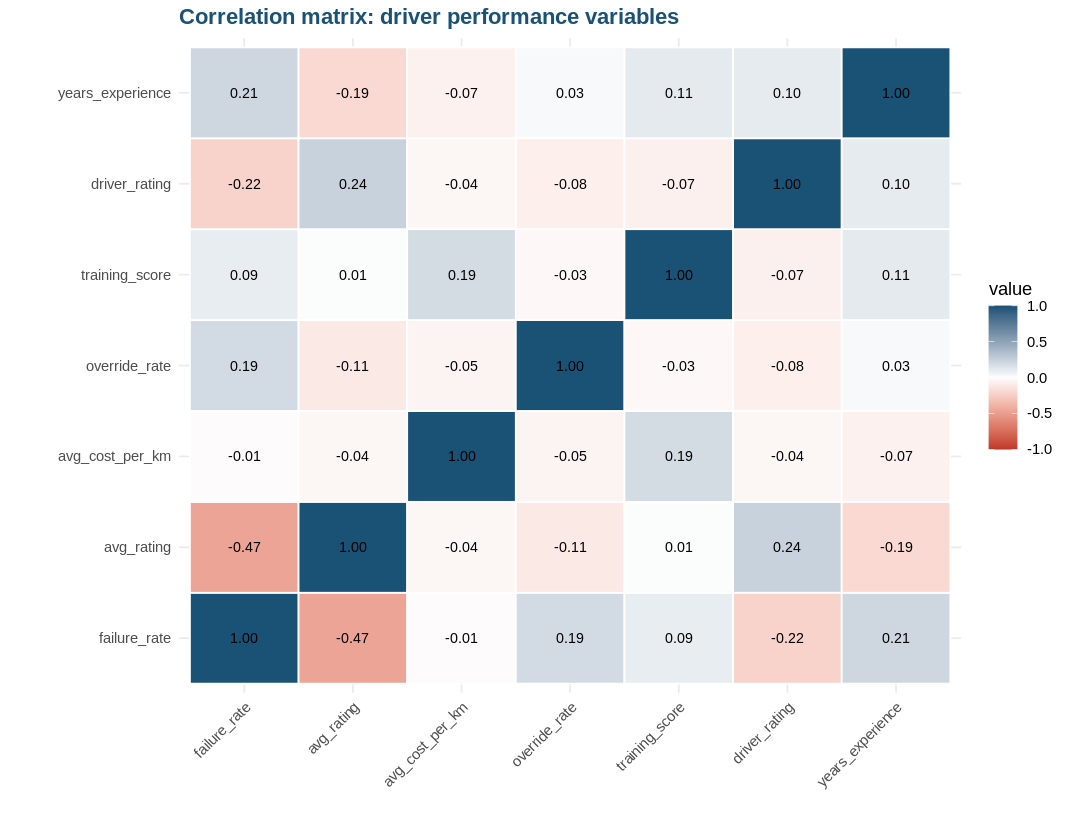

In [14]:
install.packages('reshape2', quiet=TRUE)
library(reshape2)
options(repr.plot.width=9, repr.plot.height=7)

cor_melt <- melt(cor_matrix)
ggplot(cor_melt, aes(x=Var1, y=Var2, fill=value)) +
  geom_tile(colour='white', linewidth=0.5) +
  geom_text(aes(label=sprintf('%.2f', value)), size=3, colour='black') +
  scale_fill_gradient2(low='#C0392B', mid='#FDFEFE',
    high='#1A5276', midpoint=0, limits=c(-1,1)) +
  labs(title='Correlation matrix: driver performance variables', x='', y='') +
  theme_minimal(base_size=11) +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        plot.title=element_text(face='bold', colour='#1A5276'))


`geom_smooth()` using formula = 'y ~ x'


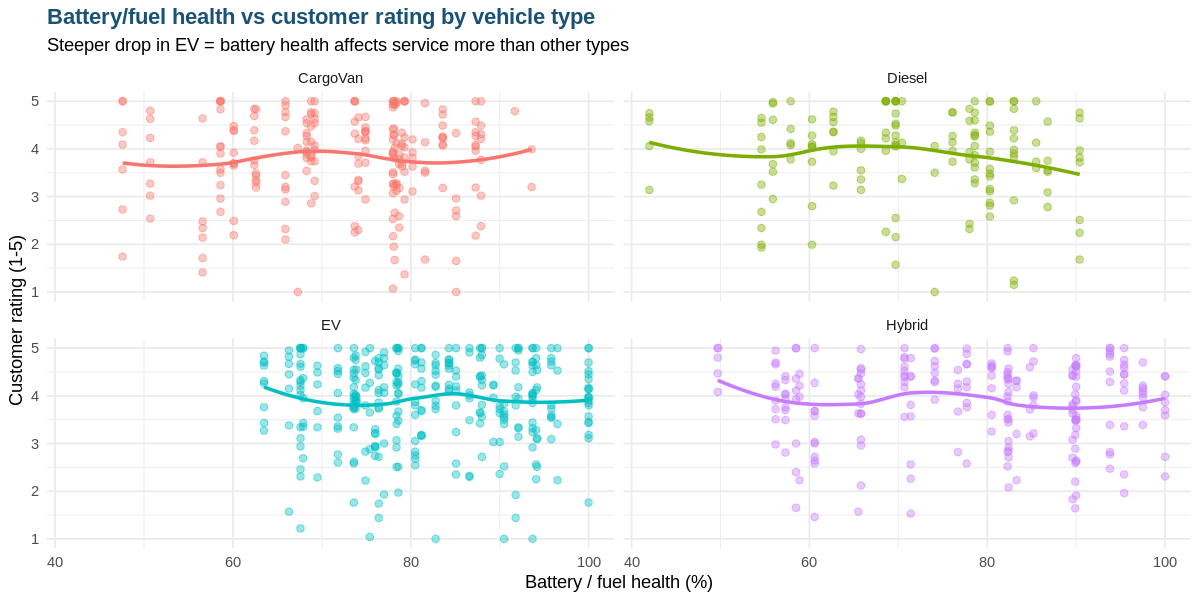

In [15]:
options(repr.plot.width=10, repr.plot.height=5)
veh_del <- ops %>%
  filter(!is.na(battery_health_pct),
         !is.na(customer_rating_post_delivery),
         !is.na(vehicle_type))

ggplot(veh_del, aes(x=battery_health_pct,
                    y=customer_rating_post_delivery,
                    colour=vehicle_type)) +
  geom_point(alpha=0.4, size=1.8) +
  geom_smooth(method='loess', se=FALSE, linewidth=1) +
  facet_wrap(~ vehicle_type, ncol=2) +
  labs(
    title    = 'Battery/fuel health vs customer rating by vehicle type',
    subtitle = 'Steeper drop in EV = battery health affects service more than other types',
    x='Battery / fuel health (%)', y='Customer rating (1-5)'
  ) +
  theme_minimal(base_size=11) +
  theme(legend.position='none',
        plot.title=element_text(face='bold', colour='#1A5276'))


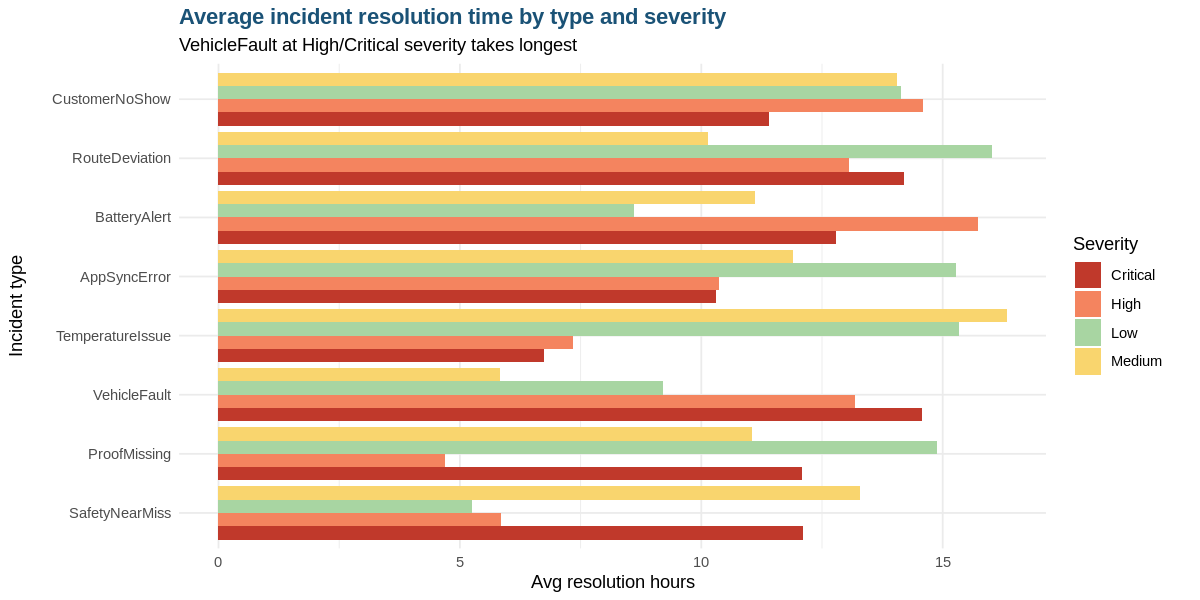

In [18]:
options(repr.plot.width=10, repr.plot.height=5)
inc_sum <- incidents %>%
  filter(!is.na(resolved_hours)) %>%
  group_by(incident_type, severity) %>%
  summarise(avg_hours=mean(resolved_hours, na.rm=TRUE),
            count=n(), .groups='drop')

ggplot(inc_sum, aes(x=reorder(incident_type, avg_hours),
                    y=avg_hours, fill=severity)) +
  geom_bar(stat='identity', position='dodge') +
  scale_fill_manual(values=c('Low'='#A8D5A2','Medium'='#F9D56E',
                              'High'='#F4845F','Critical'='#C0392B')) +
  coord_flip() +
  labs(
    title='Average incident resolution time by type and severity',
    subtitle='VehicleFault at High/Critical severity takes longest',
    x='Incident type', y='Avg resolution hours', fill='Severity'
  ) +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', colour='#1A5276'))
